In [1]:
# For Visualization (run this cell)
!pip install matplotlib

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.3 MB 220.2 kB/s eta 0:00:36
   -- -------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


**Dataset links:** https://drive.google.com/drive/folders/1w5hEC-qa5HZJiTXY8rbu1eisYqA51WJu?usp=sharing

In [2]:
import pandas as pd

In [3]:
# Read datasets
election_df = pd.read_csv("Dataset/election_data.csv")
district_df = pd.read_csv("Dataset/district_data.csv")
province_df = pd.read_csv("Dataset/province_data.csv")

In [4]:
# Check top 5 rows of election dataset
election_df.head()

,candidate_id,district_id,const_name,candidate_name,age,gender,party,votes
0,339300,4,Jhapa-5,Dharmraj Guragain,43,male,People First Party,34
1,339301,71,Kailali-5,Pyare Lal Rana,61,male,Independent,1755
2,339302,31,Makwanpur-1,Bidya Shrestha Maharjan,49,female,Shram Sanskriti Party,1024
3,339303,33,Bara-3,Chandra Prakash Suwedi,59,male,Independent,9
4,339304,35,Chitwan-3,Indra Maya Paudel,58,female,Independent,398


In [5]:
# Check the information of election dataset
election_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 3406 entries, 0 to 3405
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   candidate_id    3406 non-null   int64
 1   district_id     3406 non-null   int64
 2   const_name      3406 non-null   str  
 3   candidate_name  3406 non-null   str  
 4   age             3406 non-null   int64
 5   gender          3406 non-null   str  
 6   party           3406 non-null   str  
 7   votes           3406 non-null   int64
dtypes: int64(4), str(4)
memory usage: 213.0 KB


In [6]:
# Statistical summary of election dataset
election_df.describe()


,candidate_id,district_id,age,votes
count,3406.000000,3406.000000,3406.000000,3406.000000
mean,341043.324427,32.786553,46.959777,3091.354668
std,1009.146462,19.164638,11.276963,7793.436225
min,339300.000000,1.000000,25.000000,0.000000
25%,340169.250000,20.000000,39.000000,17.000000
50%,341039.500000,28.000000,47.000000,87.000000
75%,341917.750000,46.000000,55.000000,964.500000
max,342797.000000,77.000000,88.000000,68348.000000


In [7]:
# Find if there any null values in dataset
election_df.isnull().sum()

candidate_id      0
district_id       0
const_name        0
candidate_name    0
age               0
gender            0
party             0
votes             0
dtype: int64

#### 1. Find total number of `male` and `female` candidates. 

<Axes: xlabel='gender'>

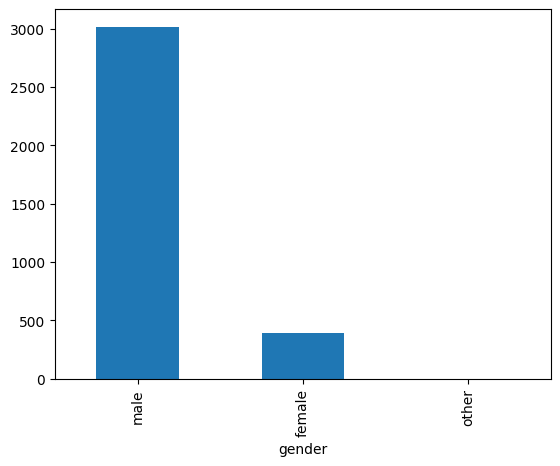

In [8]:
# Code here
# If possible, plot a bar chart
election_df['gender'].value_counts().plot(kind='bar')

#### 2. Total number of `GenZ candidates` registered for the election.

In [11]:
# Code here
# Hint: GenZ -> age between 14 to 29
election_df[election_df['age'].between(14, 29)].shape[0]

201

#### 3. Who are the `top 3 candidates` who won with the highest individual vote counts?

In [13]:
# Code here
election_df.sort_values(by='votes', ascending=False).head(3)

,candidate_id,district_id,const_name,candidate_name,age,gender,party,votes
348,339653,4,Jhapa-5,Balendra Shah,36,male,Rastriya Swatantra Party,68348
77,339380,4,Jhapa-2,Indira Rana Magar,55,female,Rastriya Swatantra Party,60110
1806,341145,35,Chitwan-3,Sobita Gautam,30,female,Rastriya Swatantra Party,59277


#### 4. Which `10 political parties` have the highest number of candidates?

In [19]:
# Code here
election_df['party'].value_counts()[1:11]

party
Nepali Congress                      165
CPN (Unified Marxist-Leninist)       164
Communist Party of Nepal             164
Rastriya Swatantra Party             164
Rastriya Prajatantra Party           163
Communist Party of Nepal (Maoist)    130
Nepal Majdoor Kisan Party            120
Mongol National Organisation         113
Shram Sanskriti Party                109
Ujyalo Nepal Party                   105
Name: count, dtype: int64

#### 5. For every `constituency`, find the candidate who received the highest votes and assign to variable `winner_df` 

In [4]:
# Code here
winner_df = election_df.loc[election_df.groupby('const_name')['votes'].idxmax()]
winner_df[winner_df['const_name'] == 'Terhathum-1']

,candidate_id,district_id,const_name,candidate_name,age,gender,party,votes
1282,340612,6,Terhathum-1,Santosh Subba,48,male,Nepali Congress,11561


In [35]:
# Calculate the percentage of female winners
winner_df['gender'].value_counts(normalize=True) * 100

gender
male      91.515152
female     8.484848
Name: proportion, dtype: float64

#### 6. Compute how many constituency each party won.

In [36]:
# Code here 
winner_df['party'].value_counts()

party
Rastriya Swatantra Party          125
Nepali Congress                    18
CPN (Unified Marxist-Leninist)      9
Communist Party of Nepal            8
Shram Sanskriti Party               3
Rastriya Prajatantra Party          1
Independent                         1
Name: count, dtype: int64

#### 7. Which province had the highest total votes casted?

In [5]:
# Code here
df = election_df.merge(district_df, on='district_id').merge(province_df, on='province_id')

df.groupby('province_name')['votes'].sum().sort_values(ascending=False)

province_name
Madhesh          2158414
Bagmati          2140729
Koshi            1953372
Lumbini          1917649
Gandaki           992578
Sudurpashchim     822944
Karnali           543468
Name: votes, dtype: int64

#### 8. For all constituencies, find the `winner` and `first runner-up` and assign that output to variable `top_2`

In [6]:
# Code here
top_2 = election_df.groupby('const_name')['votes'].nlargest(2).reset_index()
election_df.loc[top_2['level_1']]

,candidate_id,district_id,const_name,candidate_name,age,gender,party,votes
2306,341661,68,Achham-1,Bharat Kumar Swar,70,male,Nepali Congress,10759
1693,341030,68,Achham-1,Bhim Bahadur Rawal,70,male,Communist Party of Nepal,10233
1281,340611,68,Achham-2,Yagya Bahadur Bogati,50,male,CPN (Unified Marxist-Leninist),9518
2782,342150,68,Achham-2,Pushpa Bahadur Shah,64,male,Nepali Congress,9046
335,339640,44,Arghakhanchi-1,Hari Prasad Bhusal,37,male,Rastriya Swatantra Party,35023
...,...,...,...,...,...,...,...,...
1521,340855,6,Terhathum-1,Bhanu Bhakta Dhakal,64,male,CPN (Unified Marxist-Leninist),10682
2137,341485,14,Udayapur-1,Paras Mani Gelal,40,male,Rastriya Swatantra Party,30590
834,340152,14,Udayapur-1,Rajesh Kumar Rai,43,male,Shram Sanskriti Party,11606
2319,341674,14,Udayapur-2,Surya Bahadur Tamang,41,male,Rastriya Swatantra Party,14802


#### 9. Compute the `margin` between `winner` and `first runner-up` for each constituency. 

In [ ]:
# Code here
top_two_votes = election_df.loc[top_2['level_1'], ['const_name', 'votes']].copy()
margin = top_two_votes.groupby('const_name').agg(
    margin=('votes', lambda s: s.max() - s.min())
).reset_index()
margin

,candidate_id,district_id,const_name,candidate_name,age,gender,party,votes
1693,341030,68,Achham-1,Bhim Bahadur Rawal,70,male,Communist Party of Nepal,10233
2782,342150,68,Achham-2,Pushpa Bahadur Shah,64,male,Nepali Congress,9046
699,340014,44,Arghakhanchi-1,Pitambar Bhusal,54,male,CPN (Unified Marxist-Leninist),22649
1022,340345,50,Baglung-1,Bhim Bahadur Shrees Rana,51,male,Nepali Congress,11944
2010,341354,50,Baglung-2,Tek Raj Paudel,50,male,Nepali Congress,11868
...,...,...,...,...,...,...,...,...
2556,341920,40,Tanahun-2,Shankar Bhandari,57,male,Nepali Congress,14135
1792,341131,1,Taplejung-1,Gajendra Prasad Tumyang Limbu,46,male,Nepali Congress,11711
1521,340855,6,Terhathum-1,Bhanu Bhakta Dhakal,64,male,CPN (Unified Marxist-Leninist),10682
834,340152,14,Udayapur-1,Rajesh Kumar Rai,43,male,Shram Sanskriti Party,11606


#### 10. Identifies the top 10 most competitive constituency (lowest margins).

In [11]:
# Code here
if ('margin' not in margin.columns) or ('const_name' not in margin.columns):
    top_two_votes = election_df.loc[top_2['level_1'], ['const_name', 'votes']].copy()
    margin = top_two_votes.groupby('const_name').agg(
        margin=('votes', lambda s: s.max() - s.min())
    ).reset_index()

top_10_competitive = margin.nsmallest(10, 'margin')
top_10_competitive

,const_name,margin
108,Okhaldhunga-1,5
1,Achham-2,472
0,Achham-1,526
7,Bajura-1,540
43,Gulmi-2,561
24,Dailekh-1,576
133,Sankhuwasabha-1,636
4,Baglung-2,779
142,Sindhuli-1,784
39,Doti-1,787


**_Analyze this data further using your own creativity! Happy Coding🎉🎉_**